In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

pd.options.display.max_rows = None

In [2]:
sheet_name = "Rexon_test"
spreadsheet_id = "1xb7Vh2qy_2ktLIhmopuxR1j0iMxQnY5-mwfG0KY3bNQ"
sheet_id_1 = "675828049"
sheet_id_0 = "0"
csv_url_0 = f"https://docs.google.com/spreadsheets/d/{spreadsheet_id}/export?format=csv&gid={sheet_id_0}"
csv_url_1 = f"https://docs.google.com/spreadsheets/d/{spreadsheet_id}/export?format=csv&gid={sheet_id_1}"

new_LED_amp_indicator = "new LED amp"
comment_indicator = "comment"
ref_bar_indicator = "ref"
damaged_indicator = "scratched"

double_plane_num = 1


columns_with_types = {
    "bar ID": "str",
    "run ID": "str",
    "LED_mean": "float64",
    "LED_sigma": "float64",
    "cosmic_mean": "float64",
    "cosmic_sigma": "float64",
    "comment": "str",
}

In [3]:
data = pd.read_csv(csv_url_1, usecols=list(columns_with_types))
data_0 = pd.read_csv(csv_url_0, usecols=list(columns_with_types))

total_data = pd.concat([data_0, data], ignore_index=True)
total_data = total_data.fillna(0)
total_data = total_data.astype(columns_with_types)

In [4]:
class Bar:
    def __init__(self):
        self.bar_id: str = ""
        self.run_id: str = ""
        self.id: int = 0
        self.LED: float = 0
        self.LED_sigma: float = 0
        self.cosmic: float = 0
        self.cosmic_sigma: float = 0
        self.LED_ratio: float = 0
        self.cosmic_ratio: float = 0
        self.is_damaged: bool = False

    def set_from_row(self, idx, row):
        self.id = idx
        self.bar_id = row["bar ID"]
        self.run_id = row["run ID"]
        self.LED = row["LED_mean"]
        self.LED_sigma = row["LED_sigma"]
        self.cosmic = row["cosmic_mean"]
        self.cosmic_sigma = row["cosmic_sigma"]
        self.is_damaged = damaged_indicator in row[comment_indicator]
        return self

    def __str__(self):
        return f"""
*********************************
bar ID: {self.bar_id}
run ID: {self.run_id}
LED peak: {self.LED} +/- {self.LED_sigma}
cosmic peak: {self.cosmic} +/- {self.cosmic_sigma}
LED ratio: {self.LED_ratio}
cosmic_ratio: {self.cosmic_ratio}
*********************************
        """


class BarGroup:
    def __init__(self):
        self._upper_ref: Bar = None
        self._lower_ref: Bar = None
        self._bars: list[Bar] = []

    def has_bars(self):
        return len(self._bars) > 0

    @property
    def upper_ref(self):
        return self._upper_ref

    @upper_ref.setter
    def upper_ref(self, bar: Bar):
        self._upper_ref = bar

    @property
    def lower_ref(self):
        return self._lower_ref

    @lower_ref.setter
    def lower_ref(self, bar: Bar):
        self._lower_ref = bar

    @property
    def bars(self):
        return self._bars

    def add_bar(self, bar: Bar):
        self._bars.append(bar)

    def do_calculation(self):
        if self._lower_ref is None:
            self._lower_ref = self._upper_ref
        led_ref = (self._upper_ref.LED + self._lower_ref.LED) / 2.0
        cosmic_ref = (self._upper_ref.cosmic + self._lower_ref.cosmic) / 2.0
        for bar in self._bars:
            bar.cosmic_ratio = bar.cosmic / cosmic_ref
            bar.LED_ratio = bar.LED / led_ref

In [5]:
bar_groups: list[BarGroup] = []
bar_groups.append(BarGroup())
ref_counter = 0
for idx, row in total_data.iterrows():
    new_bar = Bar().set_from_row(idx, row)
    if new_LED_amp_indicator in row[comment_indicator]:
        bar_groups.append(BarGroup())
    if new_bar.bar_id == ref_bar_indicator:
        ref_counter = ref_counter + 1
        if bar_groups[-1].upper_ref is None:
            bar_groups[-1].upper_ref = new_bar
        elif ref_counter > 1:
            bar_groups[-1].upper_ref = new_bar
        else:
            bar_groups[-1].lower_ref = new_bar
            bar_groups.append(BarGroup())
            bar_groups[-1].upper_ref = new_bar
    else:
        ref_counter = 0
        bar_groups[-1].add_bar(new_bar)
bar_groups = [group for group in bar_groups if group.has_bars()]

for bar_group in bar_groups:
    bar_group.do_calculation()

In [6]:
def get_mean_no_zeros(bars: list[Bar], get_member):
    values = list(map(get_member, bars))
    values = [value for value in values if value > 0.0]
    return np.mean(values)


def concat_run_ids(bars: list[Bar]):
    run_ids = list(map(lambda x: x.run_id, bars))
    return ";".join(run_ids)


bar_dict: dict[str, list[Bar]] = {}
bar_qualities: dict[str, list[str | float | bool]] = {
    "bar_id": [],
    "run_id": [],
    "is_damaged": [],
    "LED_ratio": [],
    "cosmic_ratio": [],
}

for bar_group in bar_groups:
    for bar in bar_group.bars:
        if bar.bar_id not in bar_dict:
            bar_dict[bar.bar_id] = []
        bar_dict[bar.bar_id].append(bar)

In [7]:
for bar_id, bars in bar_dict.items():
    if len(bars) > 1:
        mean_bar = Bar()
        mean_bar.bar_id = bar_id
        mean_bar.run_id = concat_run_ids(bars)
        mean_bar.LED = get_mean_no_zeros(bars, lambda x: x.LED)
        mean_bar.LED_sigma = get_mean_no_zeros(bars, lambda x: x.LED_sigma)
        mean_bar.cosmic = get_mean_no_zeros(bars, lambda x: x.cosmic)
        mean_bar.cosmic_sigma = get_mean_no_zeros(bars, lambda x: x.cosmic_sigma)
        mean_bar.LED_ratio = get_mean_no_zeros(bars, lambda x: x.LED_ratio)
        mean_bar.cosmic_ratio = get_mean_no_zeros(bars, lambda x: x.cosmic_ratio)
    else:
        mean_bar = bars[0]
    bar_qualities["bar_id"].append(mean_bar.bar_id)
    bar_qualities["run_id"].append(mean_bar.run_id)
    bar_qualities["LED_ratio"].append(mean_bar.LED_ratio)
    bar_qualities["cosmic_ratio"].append(mean_bar.cosmic_ratio)
    bar_qualities["is_damaged"].append(mean_bar.is_damaged)

In [8]:
def transform_bar_num(val):
    plane_id = val % num_of_planes
    bar_offset = int(val / num_of_planes)
    if bar_offset % 2 == 0:
        bar_num = 25 - int(bar_offset / 2)
    else:
        bar_num = 25 + int(bar_offset / 2) + 1

    return bar_num + plane_id * 50


num_of_planes = double_plane_num * 2
bar_table = pd.DataFrame(bar_qualities)
bar_table = bar_table.sort_values(
    by=["is_damaged", "cosmic_ratio"], ascending=[True, False]
)
bar_table = bar_table.round({"LED_ratio": 3, "cosmic_ratio": 3})
bar_nums = np.vectorize(transform_bar_num)(np.arange(0, 100 * double_plane_num))
bar_nums.resize(len(bar_table.index))
bar_table["bar_num(1-based)"] = bar_nums
bar_table.to_csv("BarQualities.csv", index=False)
bar_table.head(10)

,bar_id,run_id,is_damaged,LED_ratio,cosmic_ratio,bar_num(1-based)
45,241205-8,194,False,1.109,1.611,25
11,250106-3,77,False,1.219,1.550,75
16,250106-13,88;89;93;98,False,1.195,1.508,26
13,250106-1,81,False,1.202,1.491,76
25,250106-10,114;115;117;118;119,False,1.305,1.488,24
10,250106-8,76,False,1.201,1.475,74
136,178/25,328,False,1.133,1.465,27
21,250106-9,107,False,1.328,1.465,77
46,241205-5,195,False,1.230,1.462,23
82,241205-37,257,False,1.229,1.450,73


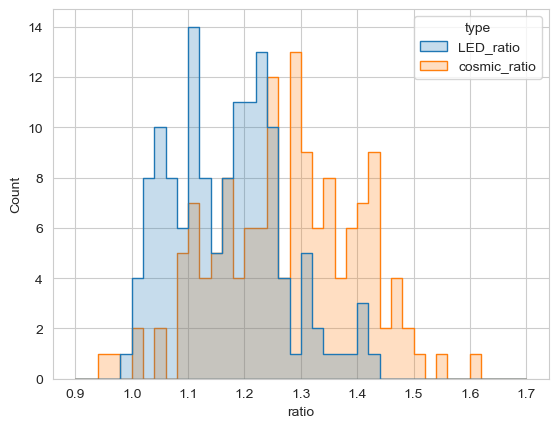

In [9]:
bar_table_long = pd.melt(
    bar_table,
    id_vars=["bar_id", "run_id", "bar_num(1-based)"],
    value_vars=["LED_ratio", "cosmic_ratio"],
    var_name="type",
    value_name="ratio",
)
sns.set_style("whitegrid")
sns.histplot(
    data=bar_table_long,
    x="ratio",
    hue="type",
    binwidth=0.02,
    element="step",
    binrange=(0.9, 1.7),
);

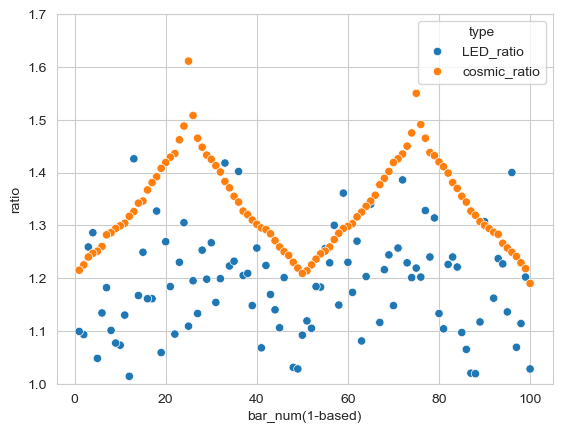

In [10]:
ax = sns.scatterplot(
    data=bar_table_long[bar_table_long["bar_num(1-based)"] != 0],
    x="bar_num(1-based)",
    y="ratio",
    hue="type",
)
ax.set(ylim=(1.0, 1.7));

In [11]:
bar_table[bar_table["bar_id"] == "250106-1"]

,bar_id,run_id,is_damaged,LED_ratio,cosmic_ratio,bar_num(1-based)
13,250106-1,81,False,1.202,1.491,76


In [12]:
# uncomment the following for bar segmentation check
# for group in bar_groups:
#     bars = group.bars
#     print("-------------")
#     if group.upper_ref is not None:
#         print(f"upper: {group.upper_ref.run_id}")
#     for bar in bars:
#         print(f"bar id: {bar.bar_id}")
#     if group.lower_ref is not None:
#         print(f"lower: {group.lower_ref.run_id}")